Interpolating host galaxy probability as function of stellar mass.

The code was written by Mária Pálfi (marika97@student.elte.hu).

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
prob_M_BBH = pd.read_csv('../Probability_Mstar_BBH_z0p1.dat', delimiter='\t', 
                         header = 0, names = ['logMs', 'P'] )

In [3]:
from scipy.interpolate import interp1d

# Assuming M_star_table and P_table are the mass and probability columns from Artale+20
interpolator = interp1d( prob_M_BBH.logMs, prob_M_BBH.P, kind='linear', fill_value='extrapolate')

# For each galaxy mass in your dataset:
interpolator(12)

array(0.13975149)

In [4]:
prob_M_BBH

,logMs,P
0,7.114583,0.000089
1,7.343750,0.000104
2,7.572917,0.000121
3,7.802083,0.000156
4,8.031250,0.000226
5,8.260417,0.000297
6,8.489583,0.000559
7,8.718750,0.000797
8,8.947917,0.000832
9,9.177083,0.001295


In [49]:
x = np.linspace(7, 12.5, 100)

In [53]:
interpolator = interp1d( prob_M_BBH.logMs, prob_M_BBH.P, kind='cubic', fill_value='extrapolate')
print( prob_M_BBH.P - interpolator(prob_M_BBH.logMs) )

0     0.000000e+00
1     0.000000e+00
2     0.000000e+00
3     0.000000e+00
4     5.421011e-20
5     0.000000e+00
6     0.000000e+00
7    -1.084202e-19
8     0.000000e+00
9    -2.168404e-19
10    0.000000e+00
11    4.336809e-19
12    0.000000e+00
13    0.000000e+00
14    1.734723e-18
15    0.000000e+00
16   -6.938894e-18
17   -6.938894e-18
18    0.000000e+00
19    0.000000e+00
20    0.000000e+00
21   -1.387779e-17
22    0.000000e+00
23    0.000000e+00
Name: P, dtype: float64


In [5]:
x = np.linspace(6, 13, 1000)

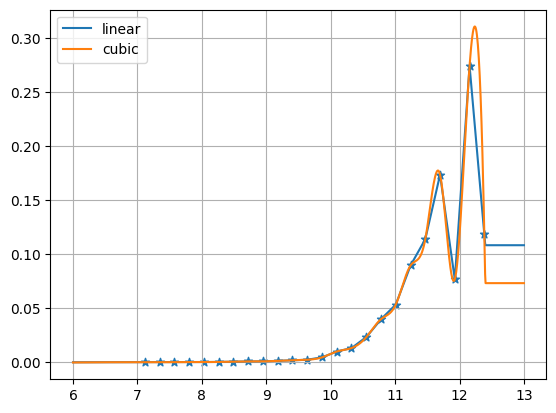

In [6]:
plt.scatter(prob_M_BBH.logMs, prob_M_BBH.P, marker = '*' )
interpolator = interp1d( prob_M_BBH.logMs, prob_M_BBH.P, kind='linear', fill_value='extrapolate')
P_linear = interpolator(x)
P_linear[x > 12.4] = interpolator(12.4)
plt.plot( x, P_linear, label = 'linear' )
interpolator = interp1d( prob_M_BBH.logMs, prob_M_BBH.P, kind='cubic', fill_value='extrapolate')
P_cubic = interpolator(x)
P_cubic[x > 12.4] = interpolator(12.4)
plt.plot( x, P_cubic, label = 'cubic' )
plt.grid()
plt.legend()

In [19]:
x = np.linspace(7, prob_M_BBH.logMs[23], 1000)

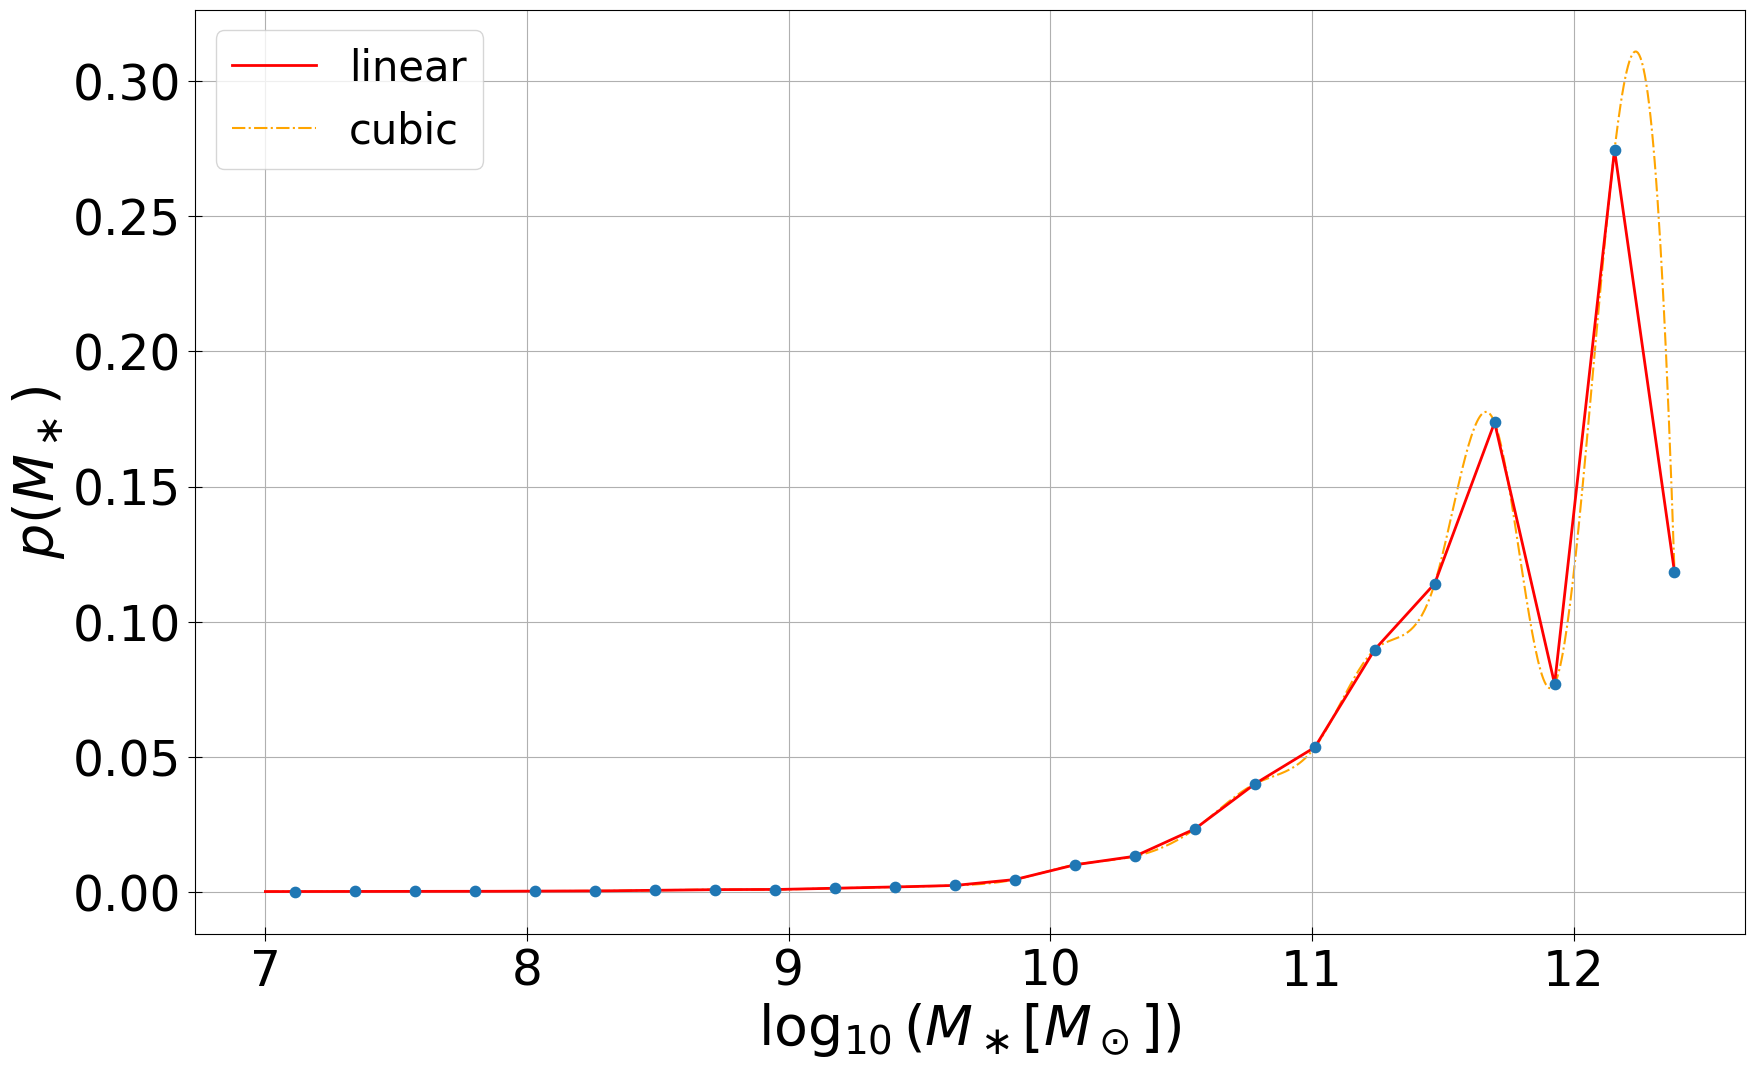

In [50]:
fig = plt.figure( figsize = (20, 12), dpi = 100 )
interpolator = interp1d( prob_M_BBH.logMs, prob_M_BBH.P, kind='linear', fill_value='extrapolate')
P_linear = interpolator(x)
P_linear[x > 12.4] = interpolator(12.4)
plt.plot( x, P_linear, label = 'linear', color = 'red', zorder = 3, lw = 2 )
interpolator = interp1d( prob_M_BBH.logMs, prob_M_BBH.P, kind='cubic', fill_value='extrapolate')
P_cubic = interpolator(x)
P_cubic[x > 12.4] = interpolator(12.4)
plt.plot( x, P_cubic, label = 'cubic', zorder = 1, ls = '-.', color = 'orange', lw = 1.5  )
plt.scatter(prob_M_BBH.logMs, prob_M_BBH.P, marker = 'o', zorder = 5, s = 55)
plt.ylabel(r'$p(M_\ast)$',  fontsize = 40 )  # Use raw string with 'r'
plt.xlabel(r'$\log_{10}(M_\ast[M_\odot])$',  fontsize =  40)  # Example with log scale
plt.xticks( fontsize = 35 )
plt.yticks( fontsize = 35 )
plt.tick_params( length=10, direction = 'inout', pad = 5 )
plt.rcParams["font.size"] = 30
plt.grid()
plt.legend()
plt.savefig('Artale_interpolated.png',dpi = 100)